# Phase 1: Data Understanding — EDA

**Branch**: `feature/data-understanding`  
**Spec**: `specs/features/01_eda_plan.md`  
**Validation checklist**: `specs/features/01_eda_validation.md`

This notebook covers all tasks from the roadmap Phase 1:
1. Setup & Imports
2. Join: TCGA Reports ↔ Cancer Type
3. Pilot Subset: BRCA / LUAD / LUSC
4. Token Length Distribution
5. Data Quality Flags (headers, token bucket, OCR noise, duplicates)
6. Report Style Sampling (synoptic vs. narrative)
7. Field Presence Audit (Group B)
8. Group A Field Presence (patient identification)
9. Summary & Hypotheses

## 1. Setup & Imports

In [19]:
import os
import sys
import warnings
from pathlib import Path

def _find_repo_root() -> Path:
    try:
        start = Path(os.getcwd())
    except (FileNotFoundError, OSError):
        start = Path(sys.executable).parent
    for p in [start, *start.parents]:
        if (p / "src").is_dir() and (p / "specs").is_dir():
            return p
    raise RuntimeError(f"Cannot find repo root from {start}")

REPO_ROOT = _find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
import tiktoken

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
CONTEXT_LIMIT = 8_000  # Llama 3 context window (conservative)
PILOT_TYPES = ["BRCA", "LUAD", "LUSC"]
DATA_DIR = Path("../data/raw")

sns.set_theme(style="whitegrid", palette="muted")
print(f"Libraries loaded. REPO_ROOT={REPO_ROOT}")

Libraries loaded. REPO_ROOT=/Users/camilasarmiento/Documents/PhD/Business/Code


In [20]:
reports_df = pd.read_csv(DATA_DIR / "TCGA_Reports.csv")
cancer_types_df = pd.read_csv(DATA_DIR / "tcga_patient_to_cancer_type.csv")
tcga_abbrev_df = pd.read_csv(DATA_DIR / "tcga_abbreviations.csv")

print(f"TCGA_Reports.csv      : {len(reports_df):,} rows, columns: {list(reports_df.columns)}")
print(f"cancer_type metadata  : {len(cancer_types_df):,} rows, columns: {list(cancer_types_df.columns)}")
print(f"TCGA abbreviations    : {len(tcga_abbrev_df):,} rows, columns: {list(tcga_abbrev_df.columns)}")


TCGA_Reports.csv      : 9,523 rows, columns: ['patient_filename', 'text']
cancer_type metadata  : 11,160 rows, columns: ['patient_id', 'cancer_type']
TCGA abbreviations    : 33 rows, columns: ['code', 'full_name']


### 1.1 Raw Data Integrity: `text` Null & Content Audit

Before joining, we confirm that `patient_filename` is unique (required for a clean merge key) and audit the `text` column for nulls, empty strings, and very short stubs that would be useless for extraction. Word-count summary stats give an early sense of report length distribution.

In [21]:
# ── patient_filename uniqueness (join-key integrity) ─────────────────────────
n_dup = reports_df["patient_filename"].duplicated().sum()
print("── patient_filename uniqueness ──────────────────")
print(f"Total rows              : {len(reports_df):,}")
print(f"Unique patient_filename : {reports_df['patient_filename'].nunique():,}")
print(f"Duplicate entries       : {n_dup} {'✓' if n_dup == 0 else '— duplicates found'}")

# ── text null / empty audit ───────────────────────────────────────────────────
n_null_text  = reports_df["text"].isnull().sum()
n_empty_text = (reports_df["text"].str.strip() == "").sum()
n_stub_text  = (reports_df["text"].str.split().str.len() < 10).sum()   # < 10 words

print("\n── text column null / empty audit ───────────────")
print(f"Null text rows              : {n_null_text}  {'✓' if n_null_text == 0 else '— ACTION NEEDED'}")
print(f"Empty / whitespace-only rows: {n_empty_text} {'✓' if n_empty_text == 0 else '— ACTION NEEDED'}")
print(f"Stub rows (< 10 words)      : {n_stub_text}")

# Show sample stubs if any
if n_stub_text > 0:
    stubs = reports_df[reports_df["text"].str.split().str.len() < 10][["patient_filename", "text"]]
    print("\nSample stubs:")
    print(stubs.head(5).to_string(index=False))

# ── text length summary stats ─────────────────────────────────────────────────
word_counts = reports_df["text"].str.split().str.len()
print("\n── text word-count summary ──────────────────────")
print(word_counts.describe().rename("word_count").to_string())

── patient_filename uniqueness ──────────────────
Total rows              : 9,523
Unique patient_filename : 9,523
Duplicate entries       : 0 ✓

── text column null / empty audit ───────────────
Null text rows              : 0  ✓
Empty / whitespace-only rows: 0 ✓
Stub rows (< 10 words)      : 2

Sample stubs:
                                 patient_filename                                                                   text
TCGA-YS-A95B.F57E6E47-4A8E-42C2-ABB8-DD81EF21DBF6 PRIMARY SITE: Pleura. Pleural biopsy. Malign epithelioid mesothelioma.
TCGA-EC-A24G.5DE142C5-7A0D-4C5E-8EF6-2809B10378C4                                                                     1.

── text word-count summary ──────────────────────
count    9523.000000
mean      560.043684
std       484.144677
min         1.000000
25%       180.000000
50%       432.000000
75%       807.500000
max      4046.000000


## 2. Join: TCGA Reports ↔ Cancer Type

`patient_id` is extracted from `patient_filename` by splitting on `.` and taking the first token:

```
TCGA-BP-5195.25c0b433-5557-...  →  TCGA-BP-5195
```

In [22]:
reports_df["patient_id"] = reports_df["patient_filename"].str.split(".").str[0]

joined_df = reports_df.merge(cancer_types_df, on="patient_id", how="left")
joined_df = joined_df.merge(
    tcga_abbrev_df.rename(columns={"code": "cancer_type", "full_name": "cancer_name"}),
    on="cancer_type",
    how="left",
)

total = len(joined_df)
matched = joined_df["cancer_type"].notna().sum()
unmatched = total - matched
match_rate = matched / total * 100

print(f"Total reports    : {total:,}")
print(f"Matched reports  : {matched:,}")
print(f"Unmatched reports: {unmatched:,}")
print(f"Match rate       : {match_rate:.2f}%")


Total reports    : 9,523
Matched reports  : 9,523
Unmatched reports: 0
Match rate       : 100.00%


In [23]:
joined_df.head()

,patient_filename,text,patient_id,cancer_type,cancer_name
0,TCGA-BP-5195.25c0b433-5557-4165-922e-2c1eac9c26f0,Date of Recelpt: Clinical Diagnosis & History:...,TCGA-BP-5195,KIRC,Kidney Renal Clear Cell Carcinoma
1,TCGA-D7-8573.b7306a47-697d-4ed3-bbe1-81d49674a8f8,"Material: 1) Material: stomach, Method of coll...",TCGA-D7-8573,STAD,Stomach Adenocarcinoma
2,TCGA-EI-7004.13591eed-30e5-47a3-91be-7a370663d2d4,page 1 / 1. copy No. 3. Examination: Histopath...,TCGA-EI-7004,READ,Rectum Adenocarcinoma
3,TCGA-EB-A82B.23E186C6-739C-4EF1-8788-79AA89C6E87A,Patient ID: Gross Description: A mass is locat...,TCGA-EB-A82B,SKCM,Skin Cutaneous Melanoma
4,TCGA-A6-3808.e1505f65-72ef-438d-a5e1-93ed8bf6635d,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,TCGA-A6-3808,COAD,Colon Adenocarcinoma


In [24]:
print("\nCancer type distribution (top 10):")
print(joined_df[[ "cancer_type","cancer_name"]].value_counts().head(10).to_string())

if unmatched > 0:
    print(f"\nNote: {unmatched} reports did not match. Sample unmatched patient_ids:")
    print(joined_df[joined_df["cancer_type"].isna()]["patient_id"].head(5).tolist())


Cancer type distribution (top 10):
cancer_type  cancer_name                          
BRCA         Breast Invasive Carcinoma                1034
UCEC         Uterine Corpus Endometrial Carcinoma      546
KIRC         Kidney Renal Clear Cell Carcinoma         525
HNSC         Head and Neck Squamous Cell Carcinoma     520
LUAD         Lung Adenocarcinoma                       488
THCA         Thyroid Carcinoma                         487
LGG          Brain Lower Grade Glioma                  469
LUSC         Lung Squamous Cell Carcinoma              468
PRAD         Prostate Adenocarcinoma                   446
COAD         Colon Adenocarcinoma                      418


## 3. Pilot Subset: BRCA / LUAD / LUSC

In [25]:
pilot_df = joined_df[joined_df["cancer_type"].isin(PILOT_TYPES)].copy()
pilot_df = pilot_df.reset_index(drop=True)

counts = pilot_df["cancer_type"].value_counts()
print("Pilot subset counts:")
print(counts.to_string())
print(f"\nTotal pilot reports: {len(pilot_df):,}")

for ct in PILOT_TYPES:
    n = counts.get(ct, 0)
    status = "PASS" if n >= 100 else "FAIL"
    print(f"  {ct}: {n} reports → {status} (need ≥ 100)")

Pilot subset counts:
cancer_type
BRCA    1034
LUAD     488
LUSC     468

Total pilot reports: 1,990
  BRCA: 1034 reports → PASS (need ≥ 100)
  LUAD: 488 reports → PASS (need ≥ 100)
  LUSC: 468 reports → PASS (need ≥ 100)


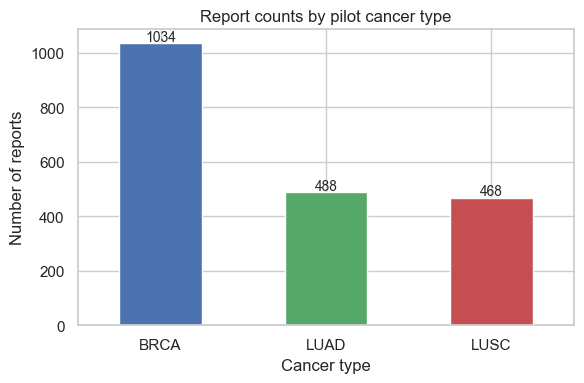

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_title("Report counts by pilot cancer type")
ax.set_xlabel("Cancer type")
ax.set_ylabel("Number of reports")
ax.set_xticklabels(counts.index, rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

### 3.1 Institution Baseline (TCGA Site Code)

TCGA patient IDs encode the contributing institution as the second segment (e.g. `TCGA-44-...` → site `44`). Different institutions used different report templates, which likely produces differences in report style and field completeness. This baseline counts how many institutions are represented and how their reports are distributed — groundwork for stratifying evaluation metrics by institution in Phase 4.

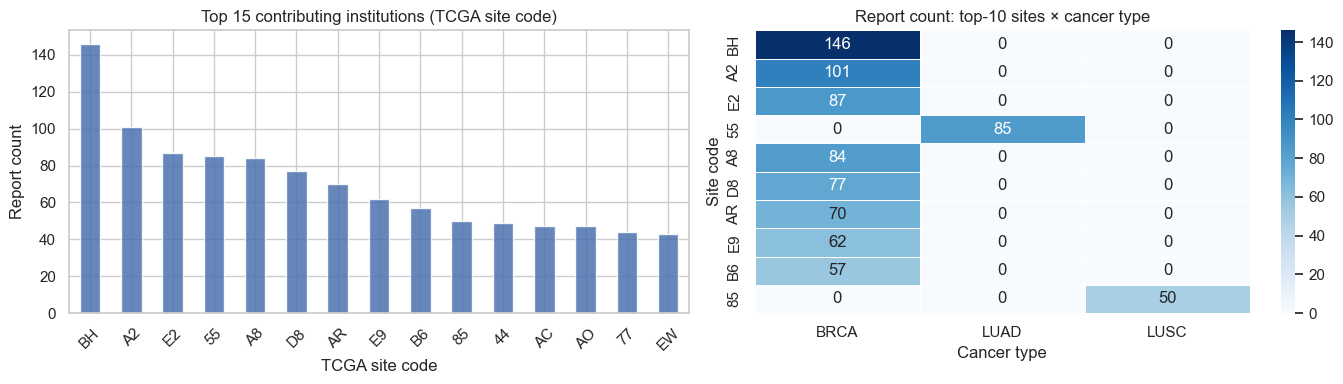

Unique institutions in pilot corpus: 102

Top 10 sites (report count):
site_code
BH    146
A2    101
E2     87
55     85
A8     84
D8     77
AR     70
E9     62
B6     57
85     50


In [27]:
pilot_df["site_code"] = pilot_df["patient_id"].str.split("-").str[1]

site_counts = pilot_df["site_code"].value_counts()
TOP_N = 15

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Top sites by report count
site_counts.head(TOP_N).plot(
    kind="bar", ax=axes[0], color="#4C72B0", alpha=0.85, edgecolor="white"
)
axes[0].set_title(f"Top {TOP_N} contributing institutions (TCGA site code)")
axes[0].set_xlabel("TCGA site code")
axes[0].set_ylabel("Report count")
axes[0].tick_params(axis="x", rotation=45)

# (b) Site × cancer type heatmap (top 10 sites)
top_sites = site_counts.head(10).index
hm_data = (
    pd.crosstab(
        pilot_df.loc[pilot_df["site_code"].isin(top_sites), "site_code"],
        pilot_df.loc[pilot_df["site_code"].isin(top_sites), "cancer_type"],
    )
    .reindex(top_sites)
)
sns.heatmap(hm_data, annot=True, fmt="d", cmap="Blues", ax=axes[1], linewidths=0.5)
axes[1].set_title("Report count: top-10 sites × cancer type")
axes[1].set_xlabel("Cancer type")
axes[1].set_ylabel("Site code")

plt.tight_layout()
plt.show()

print(f"Unique institutions in pilot corpus: {pilot_df['site_code'].nunique()}")
print(f"\nTop 10 sites (report count):")
print(site_counts.head(10).to_string())

## 4. Token Length Distribution

Using `tiktoken` with the `cl100k_base` encoder (gpt-4o tokenizer). Context limit flag: **8,000 tokens** (Llama 3 conservative limit).

In [28]:
enc = tiktoken.get_encoding("cl100k_base")

def count_tokens(text: str) -> int:
    if not isinstance(text, str):
        return 0
    return len(enc.encode(text))

print("Counting tokens for all pilot reports (this may take ~30s)...")
pilot_df["token_count"] = pilot_df["text"].apply(count_tokens)
print("Done.")

Counting tokens for all pilot reports (this may take ~30s)...
Done.


In [29]:
stats = pilot_df["token_count"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
print("Token length summary statistics:")
print(stats.round(0).to_string())

over_limit = (pilot_df["token_count"] > CONTEXT_LIMIT).sum()
pct_over = over_limit / len(pilot_df) * 100
print(f"\nReports exceeding {CONTEXT_LIMIT:,} tokens: {over_limit} ({pct_over:.1f}%)")

Token length summary statistics:
count    1990.0
mean     1118.0
std       875.0
min        40.0
25%       350.0
50%       984.0
75%      1634.0
95%      2671.0
99%      3899.0
max      6942.0

Reports exceeding 8,000 tokens: 0 (0.0%)


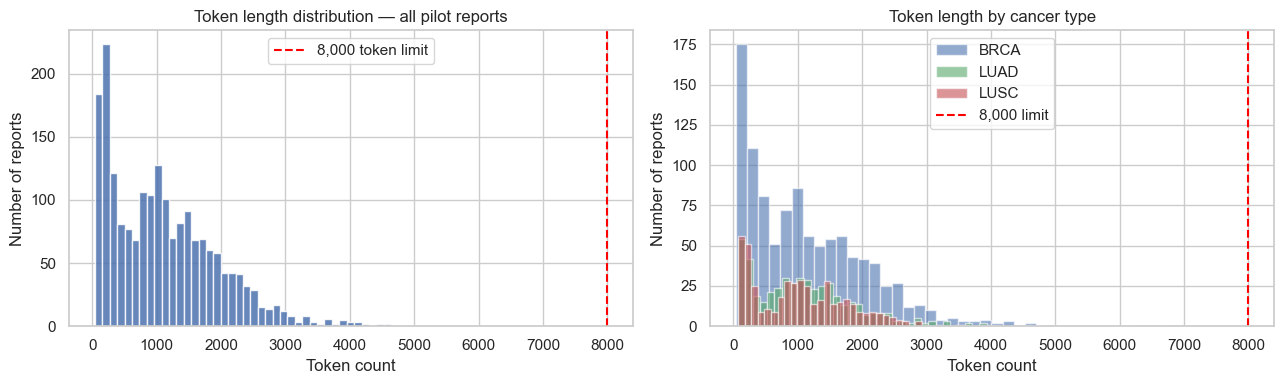

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full distribution
axes[0].hist(pilot_df["token_count"], bins=60, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(CONTEXT_LIMIT, color="red", linestyle="--", linewidth=1.5, label=f"{CONTEXT_LIMIT:,} token limit")
axes[0].set_title("Token length distribution — all pilot reports")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Number of reports")
axes[0].legend()

# By cancer type
for ct, color in zip(PILOT_TYPES, ["#4C72B0", "#55A868", "#C44E52"]):
    subset = pilot_df[pilot_df["cancer_type"] == ct]["token_count"]
    axes[1].hist(subset, bins=40, alpha=0.6, label=ct, color=color, edgecolor="white")
axes[1].axvline(CONTEXT_LIMIT, color="red", linestyle="--", linewidth=1.5, label=f"{CONTEXT_LIMIT:,} limit")
axes[1].set_title("Token length by cancer type")
axes[1].set_xlabel("Token count")
axes[1].set_ylabel("Number of reports")
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
# Per cancer type: reports over limit
print("Over-limit reports by cancer type:")
for ct in PILOT_TYPES:
    subset = pilot_df[pilot_df["cancer_type"] == ct]
    n_over = (subset["token_count"] > CONTEXT_LIMIT).sum()
    pct = n_over / len(subset) * 100
    print(f"  {ct}: {n_over}/{len(subset)} ({pct:.1f}%) exceed {CONTEXT_LIMIT:,} tokens")

# ── MAXIMUM threshold ─────────────────────────────────────────────────────────
p95 = int(pilot_df["token_count"].quantile(0.95))
print(f"\n--- TRUNCATION THRESHOLD (maximum) ---")
print(f"p95 token count : {p95:,}")
print(f"Threshold set   : {CONTEXT_LIMIT:,} tokens (first N tokens retained if exceeded)")
print(f"Rationale       : 0% of pilot reports exceed this limit — no truncation needed in practice.")



Over-limit reports by cancer type:
  BRCA: 0/1034 (0.0%) exceed 8,000 tokens
  LUAD: 0/488 (0.0%) exceed 8,000 tokens
  LUSC: 0/468 (0.0%) exceed 8,000 tokens

--- TRUNCATION THRESHOLD (maximum) ---
p95 token count : 2,671
Threshold set   : 8,000 tokens (first N tokens retained if exceeded)
Rationale       : 0% of pilot reports exceed this limit — no truncation needed in practice.


## 5. Data Quality Flags

Each report in the pilot corpus is automatically scanned for five data-quality signals. These flags are stored as columns in `pilot_df` and used in Phase 2 to guide cleaning, evaluation set curation, and prompt-engineering decisions.

| Flag | Description |
|---|---|
| `has_headers` | Report contains ≥ 2 uppercase colon-terminated section labels (e.g. `MACROSCOPIC DESCRIPTION:`) |
| `token_bucket` | Length category: `very_short` (<100 tokens), `short` (100–500), `medium` (500–2,000), `long` (>2,000). Section 1.1 found true stubs in the full corpus — the 30-token minimum floor (Section 4) is the exclusion mechanism. |
| `ocr_noise` | Suspected OCR artefacts: spaced letters (e.g. `S U P P L E M E N T`) or garbled mixed-case tokens (e.g. `INTTRAOPERATVR`) |
| `duplicate_content` | Text is an exact or near-exact duplicate of another report in the corpus (SHA-256 + 300-char prefix) |
| `tabular_format` | Text is a spreadsheet row or database export, not a clinical report (detected via spreadsheet-header phrases such as "data description worksheet", "yellow tab") |

In [32]:
from src.features import (
    apply_quality_flags,
    detect_headers, header_detail,
    detect_ocr_noise, ocr_noise_detail,
    detect_tabular_format,
    build_duplicate_flags,
    token_bucket,
)

print("Applying data-quality flags …")
pilot_df = apply_quality_flags(pilot_df)
print("Done.")


Applying data-quality flags …
Done.


Data-quality flag summary (pilot corpus, n=1,990)

             Flag  Flagged (n)  Flagged (%)
      has_headers         1147         57.6
        ocr_noise           11          0.6
duplicate_content           39          2.0
   tabular_format           12          0.6

Token bucket distribution:
token_bucket
very_short      60
short          548
medium        1085
long           297

Note: very_short can be a true stub (e.g. TCGA-EC-A24G = '1.', Section 1.1)
      or a dense synoptic (e.g. TCGA-A8-* BRCA). The 30-token floor
      (Section 4) is the exclusion mechanism — not this bucket label alone.


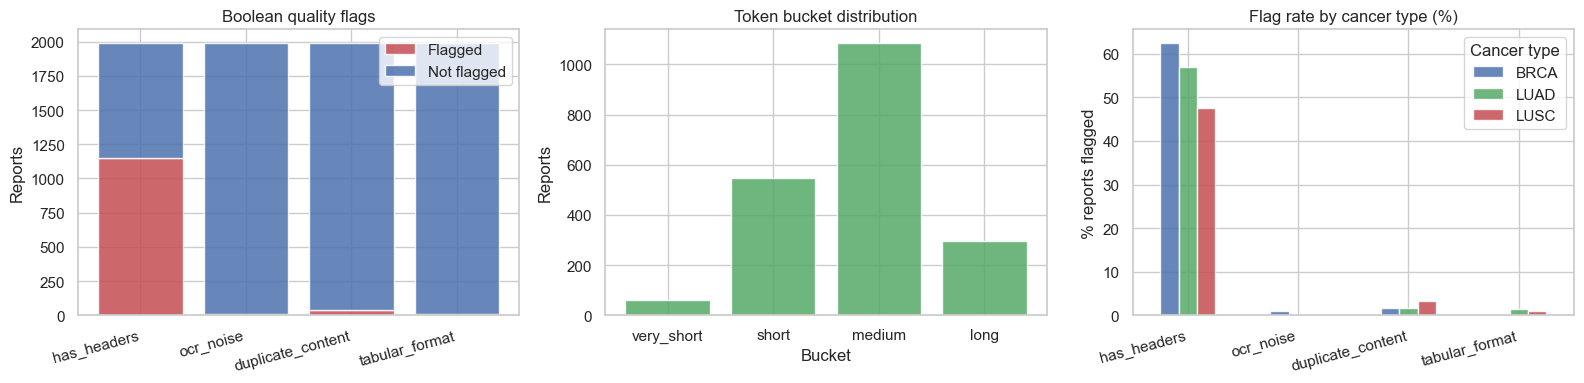

In [33]:
total = len(pilot_df)
bool_flags = ["has_headers", "ocr_noise", "duplicate_content", "tabular_format"]

# ── Summary table ─────────────────────────────────────────────────────────────
flag_summary = pd.DataFrame({
    "Flag": bool_flags,
    "Flagged (n)": [pilot_df[f].sum() for f in bool_flags],
})
flag_summary["Flagged (%)"] = (flag_summary["Flagged (n)"] / total * 100).round(1)
print(f"Data-quality flag summary (pilot corpus, n={total:,})\n")
print(flag_summary.to_string(index=False))

bucket_order  = ["very_short", "short", "medium", "long"]
bucket_counts = pilot_df["token_bucket"].value_counts().reindex(bucket_order).fillna(0).astype(int)
print("\nToken bucket distribution:")
print(bucket_counts.to_string())
print(f"\nNote: very_short can be a true stub (e.g. TCGA-EC-A24G = '1.', Section 1.1)")
print(f"      or a dense synoptic (e.g. TCGA-A8-* BRCA). The 30-token floor")
print(f"      (Section 4) is the exclusion mechanism — not this bucket label alone.")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# (a) Boolean flags
counts_true  = [int(pilot_df[f].sum()) for f in bool_flags]
counts_false = [total - c for c in counts_true]
x = np.arange(len(bool_flags))
axes[0].bar(x, counts_true,  label="Flagged",     color="#C44E52", alpha=0.85)
axes[0].bar(x, counts_false, bottom=counts_true, label="Not flagged", color="#4C72B0", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(bool_flags, rotation=15, ha="right")
axes[0].set_ylabel("Reports")
axes[0].set_title("Boolean quality flags")
axes[0].legend()

# (b) Token bucket
axes[1].bar(bucket_order, bucket_counts.values, color="#55A868", alpha=0.85, edgecolor="white")
axes[1].set_ylabel("Reports")
axes[1].set_title("Token bucket distribution")
axes[1].set_xlabel("Bucket")

# (c) Flag rate by cancer type
flag_by_ct = pilot_df.groupby("cancer_type")[bool_flags].mean() * 100
flag_by_ct.T.plot(kind="bar", ax=axes[2], color=["#4C72B0", "#55A868", "#C44E52"], alpha=0.85, edgecolor="white")
axes[2].set_ylabel("% reports flagged")
axes[2].set_title("Flag rate by cancer type (%)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha="right")
axes[2].legend(title="Cancer type")

plt.tight_layout()
plt.show()

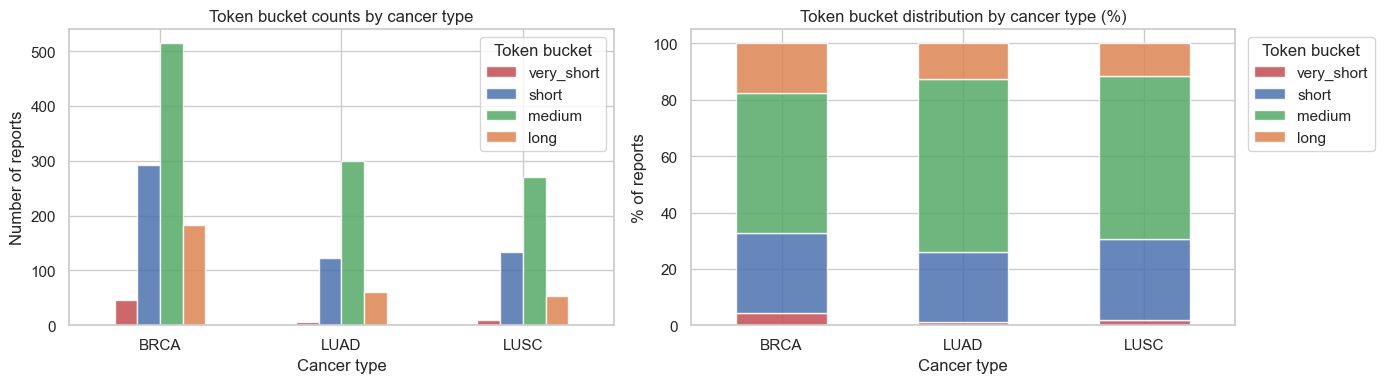


Token bucket counts by cancer type:
token_bucket  very_short  short  medium  long
cancer_type                                  
BRCA                  46    292     514   182
LUAD                   5    122     300    61
LUSC                   9    134     271    54

Token bucket distribution by cancer type (%):
token_bucket  very_short  short  medium  long
cancer_type                                  
BRCA                 4.4   28.2    49.7  17.6
LUAD                 1.0   25.0    61.5  12.5
LUSC                 1.9   28.6    57.9  11.5


In [34]:
# Token bucket distribution by cancer type
bucket_order = ["very_short", "short", "medium", "long"]
bucket_colors = ["#C44E52", "#4C72B0", "#55A868", "#DD8452"]

bucket_by_ct = (
    pd.crosstab(pilot_df["cancer_type"], pilot_df["token_bucket"])
    .reindex(columns=bucket_order)
    .fillna(0)
    .astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# (a) Absolute counts stacked bar
bucket_by_ct.plot(
    kind="bar", ax=axes[0], color=bucket_colors, alpha=0.85, edgecolor="white"
)
axes[0].set_title("Token bucket counts by cancer type")
axes[0].set_xlabel("Cancer type")
axes[0].set_ylabel("Number of reports")
axes[0].set_xticklabels(bucket_by_ct.index, rotation=0)
axes[0].legend(title="Token bucket", labels=bucket_order)

# (b) Normalised (%) stacked bar
bucket_by_ct_pct = bucket_by_ct.div(bucket_by_ct.sum(axis=1), axis=0) * 100
bucket_by_ct_pct.plot(
    kind="bar", stacked=True, ax=axes[1], color=bucket_colors, alpha=0.85, edgecolor="white"
)
axes[1].set_title("Token bucket distribution by cancer type (%)")
axes[1].set_xlabel("Cancer type")
axes[1].set_ylabel("% of reports")
axes[1].set_xticklabels(bucket_by_ct_pct.index, rotation=0)
axes[1].legend(title="Token bucket", labels=bucket_order, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

print("\nToken bucket counts by cancer type:")
print(bucket_by_ct.to_string())
print("\nToken bucket distribution by cancer type (%):")
print(bucket_by_ct_pct.round(1).to_string())

## 6. Report Style Classification (synoptic vs. narrative)

The rule-based classifier is applied to **all pilot reports**. Style labels are assigned automatically by extracting structural signals from the report text — no manual annotation is required.

**Style definitions:**
- **synoptic** — structured checklist format with explicit labelled fields
- **narrative** — free-prose paragraphs embedding findings in running text
- **mixed** — contains both structured and narrative sections

In [35]:
# --- Rule-based style classification ---
# Logic lives in src/features.py (classify_style, extract_structural_signals,
# classify_style_from_signals). Imported here to keep notebooks thin.

from src.features import classify_style, extract_structural_signals, classify_style_from_signals

pilot_df["style"] = pilot_df["text"].apply(classify_style)

print("Style distribution in sample (rule-based):")
print(pilot_df["style"].value_counts().to_string())
print()
print("Style by cancer type:")
print(pd.crosstab(pilot_df["cancer_type"], pilot_df["style"]))

Style distribution in sample (rule-based):
style
mixed        909
synoptic     891
narrative    190

Style by cancer type:
style        mixed  narrative  synoptic
cancer_type                            
BRCA           420         87       527
LUAD           269         44       175
LUSC           220         59       189


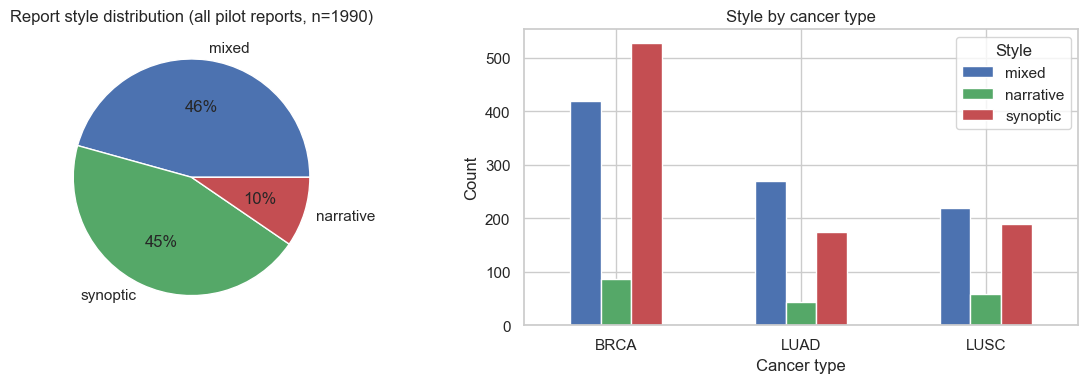

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

style_counts = pilot_df["style"].value_counts()
axes[0].pie(
    style_counts.values,
    labels=style_counts.index,
    autopct="%1.0f%%",
    colors=["#4C72B0", "#55A868", "#C44E52"]
)
axes[0].set_title(f"Report style distribution (all pilot reports, n={len(pilot_df)})")

pd.crosstab(pilot_df["cancer_type"], pilot_df["style"]).plot(
    kind="bar", ax=axes[1], color=["#4C72B0", "#55A868", "#C44E52"]
)
axes[1].set_title("Style by cancer type")
axes[1].set_xlabel("Cancer type")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title="Style")

plt.tight_layout()
plt.show()

### Style classification notes

**Observation**: The TCGA corpus contains a mixture of all three styles. Many reports combine a synoptic diagnosis section (standardised headers) with a narrative gross/microscopic description section — these are classified as `mixed`. The rule-based classifier uses five structural-boundary patterns (`_ALLCAPS_COLON`, `_ALLCAPS_PERIOD`, `_TITLECASE_COLON`, `_NUMBERED_PERIOD`, `_NUMBERED_COLON`) to compute `structure_density` and `prose_fraction`, which drive the label assignment.

**Initial hypothesis H1**: Synoptic and mixed-style reports will yield higher extraction accuracy than pure-narrative reports, because field labels in synoptic sections serve as anchors for the LLM. This will be tested in Phase 4 by stratifying evaluation metrics by style.

In [37]:
# --- Structural signal analysis ---
# Apply extract_structural_signals (defined above) to the sample and inspect
# mean signal values grouped by the rule-derived style label.
# This verifies that the signals are directionally consistent with the
# classification: synoptic should show high structure_density / low prose_fraction,
# narrative the opposite.

signals    = pilot_df["text"].apply(extract_structural_signals).apply(pd.Series)
signals_df = pd.concat([pilot_df[["patient_id", "cancer_type", "style"]], signals], axis=1)

print("Mean signals by rule-derived style label:")
print(signals_df.groupby("style")[list(signals.columns)].mean().round(2).to_string())


Mean signals by rule-derived style label:
           allcaps_colon_count  allcaps_period_count  titlecase_colon_count  numbered_item_count  total_structure_count  structure_density  prose_fraction  max_prose_run  avg_prose_run
style                                                                                                                                                                                   
mixed                     6.91                  9.33                  23.13                14.11                  47.75               6.16            0.63         193.45          17.87
narrative                 0.38                  0.84                   3.06                 0.98                   4.92               2.28            0.94         141.44          42.17
synoptic                 11.42                 17.32                  26.70                17.12                  63.82              14.89            0.24          78.72           7.74


In [38]:
signals_df

,patient_id,cancer_type,style,allcaps_colon_count,allcaps_period_count,titlecase_colon_count,numbered_item_count,total_structure_count,structure_density,prose_fraction,max_prose_run,avg_prose_run
0,TCGA-44-8119,LUAD,mixed,0.0,0.0,21.0,25.0,46.0,5.19,0.541,205.0,18.9
1,TCGA-44-6777,LUAD,mixed,2.0,5.0,11.0,1.0,17.0,6.07,0.511,143.0,15.6
2,TCGA-56-7579,LUSC,mixed,13.0,19.0,50.0,49.0,125.0,7.39,0.540,195.0,13.4
3,TCGA-34-7107,LUSC,synoptic,20.0,20.0,25.0,27.0,76.0,22.03,0.000,15.0,4.5
4,TCGA-A8-A08B,BRCA,mixed,0.0,0.0,2.0,1.0,3.0,11.54,0.000,18.0,6.5
...,...,...,...,...,...,...,...,...,...,...,...,...
1985,TCGA-A7-A0CH,BRCA,mixed,2.0,9.0,22.0,20.0,51.0,9.53,0.579,140.0,10.4
1986,TCGA-J1-A4AH,LUSC,synoptic,16.0,42.0,18.0,82.0,143.0,11.96,0.334,84.0,8.3
1987,TCGA-A8-A08I,BRCA,narrative,0.0,0.0,1.0,1.0,2.0,3.45,0.983,57.0,19.3
1988,TCGA-62-A46P,LUAD,mixed,0.0,0.0,3.0,0.0,3.0,9.68,0.000,15.0,7.8


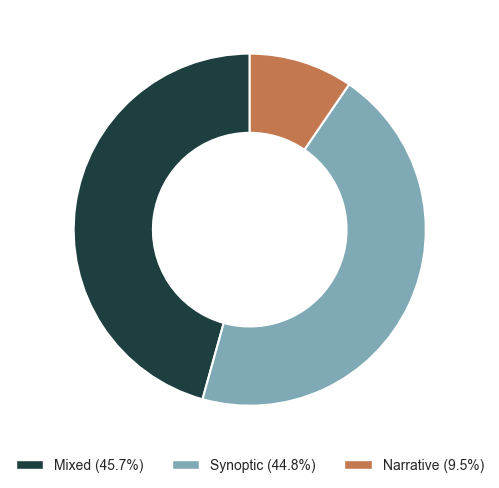

In [24]:
import matplotlib.patches as mpatches

# ── Donut chart: report style distribution ────────────────────────────────────
DONUT_COLORS = {"mixed": "#1d3f3f", "synoptic": "#7faab5", "narrative": "#c47850"}
STYLE_ORDER  = ["mixed", "synoptic", "narrative"]

style_cnts = pilot_df["style"].value_counts()
total_n    = len(pilot_df)

sizes  = [style_cnts.get(s, 0) for s in STYLE_ORDER]
colors = [DONUT_COLORS[s] for s in STYLE_ORDER]

fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    sizes,
    colors=colors,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=1.5),
    startangle=90,
)

legend_handles = [
    mpatches.Patch(
        facecolor=DONUT_COLORS[s],
        label=f"{s.capitalize()} ({style_cnts.get(s, 0) / total_n * 100:.1f}%)"
    )
    for s in STYLE_ORDER
]
ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False,
    fontsize=10,
)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")
plt.tight_layout()
plt.show()

### 6.3 Style × Data Quality Cross-tabs

Cross-tabulating style against data quality flags reveals whether OCR noise or token length bias the classifier. The key risk: garbled OCR text obscures structural markers, potentially mis-labelling noisy reports as `narrative`. 

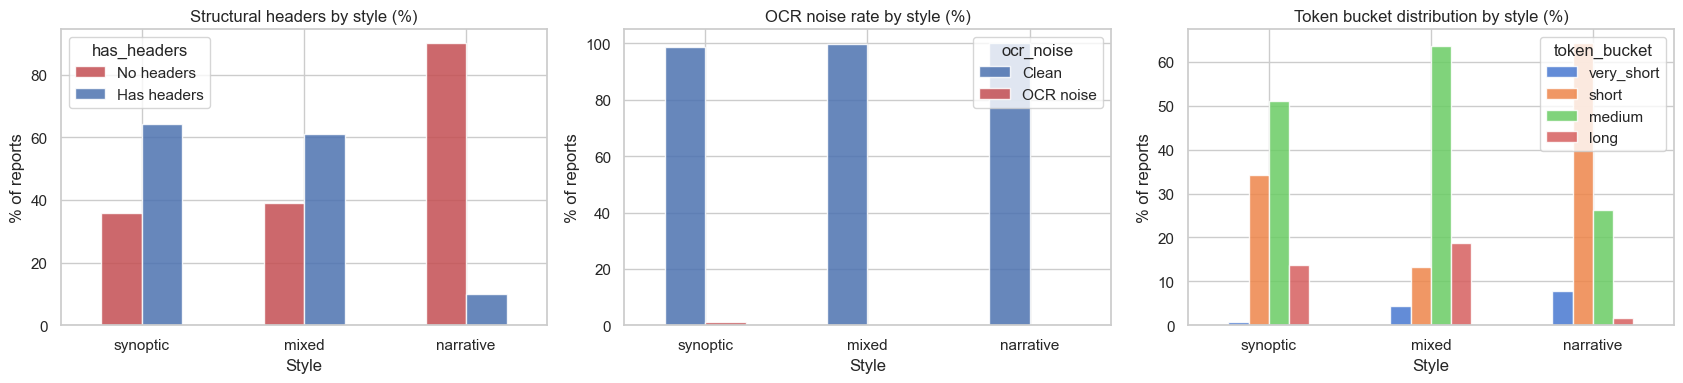

OCR noise rate by style (%):
ocr_noise  False  True 
style                  
synoptic    98.9    1.1
mixed       99.9    0.1
narrative  100.0    0.0

Median token count by style:
style
synoptic      879.0
mixed        1176.0
narrative     278.5


In [39]:
STYLE_ORDER  = ["synoptic", "mixed", "narrative"]
BUCKET_ORDER = ["very_short", "short", "medium", "long"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# (a) style × has_headers
ct_headers = (
    pd.crosstab(pilot_df["style"], pilot_df["has_headers"], normalize="index") * 100
).reindex(STYLE_ORDER)
ct_headers.columns = ["No headers", "Has headers"]
ct_headers.plot(kind="bar", ax=axes[0], color=["#C44E52", "#4C72B0"], alpha=0.85, edgecolor="white")
axes[0].set_title("Structural headers by style (%)")
axes[0].set_xlabel("Style")
axes[0].set_ylabel("% of reports")
axes[0].set_xticklabels(STYLE_ORDER, rotation=0)
axes[0].legend(title="has_headers")

# (b) style × ocr_noise
ct_ocr = (
    pd.crosstab(pilot_df["style"], pilot_df["ocr_noise"], normalize="index") * 100
).reindex(STYLE_ORDER)
ct_ocr.columns = ["Clean", "OCR noise"]
ct_ocr.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"], alpha=0.85, edgecolor="white")
axes[1].set_title("OCR noise rate by style (%)")
axes[1].set_xlabel("Style")
axes[1].set_ylabel("% of reports")
axes[1].set_xticklabels(STYLE_ORDER, rotation=0)
axes[1].legend(title="ocr_noise")

# (c) style × token_bucket
ct_bucket = (
    pd.crosstab(pilot_df["style"], pilot_df["token_bucket"], normalize="index") * 100
).reindex(STYLE_ORDER)[BUCKET_ORDER]
ct_bucket.plot(kind="bar", ax=axes[2], alpha=0.85, edgecolor="white")
axes[2].set_title("Token bucket distribution by style (%)")
axes[2].set_xlabel("Style")
axes[2].set_ylabel("% of reports")
axes[2].set_xticklabels(STYLE_ORDER, rotation=0)
axes[2].legend(BUCKET_ORDER, title="token_bucket")

plt.tight_layout()
plt.show()

print("OCR noise rate by style (%):")
print(
    (pd.crosstab(pilot_df["style"], pilot_df["ocr_noise"], normalize="index") * 100)
    .reindex(STYLE_ORDER)
    .round(1)
    .to_string()
)
print("\nMedian token count by style:")
print(pilot_df.groupby("style")["token_count"].median().reindex(STYLE_ORDER).to_string())

## 7. Field Presence Audit (Group B)

Regex searches across all pilot reports. Patterns are case-insensitive.

In [50]:
field_patterns = {
    "TNM_T": r"(?:p|yp|c)?T[0-4x](?:[a-c])?\b",
    "TNM_N": r"(?:p|yp|c)?N[0-3x](?:[a-c])?\b",
    "TNM_M": r"(?:p|c)?M[01x]\b",
    "Grade": r"grade\s+[I-IViv1-4]+|G[1-4]\b|Fuhrman|Gleason|well[- ]differentiated|moderately[- ]differentiated|poorly[- ]differentiated",
    "Histology": r"adenocarcinoma|squamous|carcinoma|sarcoma|lymphoma|melanoma|glioma|mesothelioma",
    "Specimen_type": r"resection|biopsy|excision|nephrectomy|mastectomy|lobectomy|pneumonectomy|wedge",
    # Anatomical specificity: laterality + organ, subsite, or explicit site header.
    # Bare organ names (breast, lung) are excluded — trivially ~100% in a pre-stratified corpus.
    "Primary_site": (
        r"\b(left|right)\s+(breast|lung|lobe)\b"          # laterality + organ/lobe
        r"|\b(upper|lower)\s+(outer|inner)\s+quadrant\b"  # breast quadrant
        r"|\bnipple\b|\bareola\b|\baxillary\s+tail\b"     # breast subsite
        r"|\b(upper|middle|lower)\s+lobe\b"               # lung lobe
        r"|\bmain\s+(?:stem\s+)?bronchus\b"               # lung bronchus
        r"|primary\s+site\s*[:\-=]|site\s+of\s+origin"   # explicit site header
    ),
}

def field_present(text: str, pattern: str) -> bool:
    if not isinstance(text, str):
        return False
    return bool(re.search(pattern, text, flags=re.IGNORECASE))

for field, pattern in field_patterns.items():
    pilot_df[f"has_{field}"] = pilot_df["text"].apply(lambda t: field_present(t, pattern))

print("Field presence across all pilot reports:")
print(f"{'Field':<20} {'Present':>10} {'Total':>8} {'Rate':>8}")
print("-" * 50)
for field in field_patterns:
    col = f"has_{field}"
    n = pilot_df[col].sum()
    total_n = len(pilot_df)
    rate = n / total_n * 100
    print(f"{field:<20} {n:>10,} {total_n:>8,} {rate:>7.1f}%")

Field presence across all pilot reports:
Field                   Present    Total     Rate
--------------------------------------------------
TNM_T                     1,112    1,990    55.9%
TNM_N                       671    1,990    33.7%
TNM_M                       677    1,990    34.0%
Grade                     1,638    1,990    82.3%
Histology                 1,968    1,990    98.9%
Specimen_type             1,800    1,990    90.5%
Primary_site              1,701    1,990    85.5%


In [41]:
print("\nField presence by cancer type:")
for field in field_patterns:
    col = f"has_{field}"
    print(f"\n{field}:")
    for ct in PILOT_TYPES:
        subset = pilot_df[pilot_df["cancer_type"] == ct]
        n = subset[col].sum()
        rate = n / len(subset) * 100
        print(f"  {ct}: {n}/{len(subset)} ({rate:.1f}%)")


Field presence by cancer type:

TNM_T:
  BRCA: 506/1034 (48.9%)
  LUAD: 335/488 (68.6%)
  LUSC: 271/468 (57.9%)

TNM_N:
  BRCA: 312/1034 (30.2%)
  LUAD: 194/488 (39.8%)
  LUSC: 165/468 (35.3%)

TNM_M:
  BRCA: 278/1034 (26.9%)
  LUAD: 215/488 (44.1%)
  LUSC: 184/468 (39.3%)

Grade:
  BRCA: 855/1034 (82.7%)
  LUAD: 405/488 (83.0%)
  LUSC: 378/468 (80.8%)

Histology:
  BRCA: 1031/1034 (99.7%)
  LUAD: 478/488 (98.0%)
  LUSC: 459/468 (98.1%)

Specimen_type:
  BRCA: 938/1034 (90.7%)
  LUAD: 450/488 (92.2%)
  LUSC: 412/468 (88.0%)


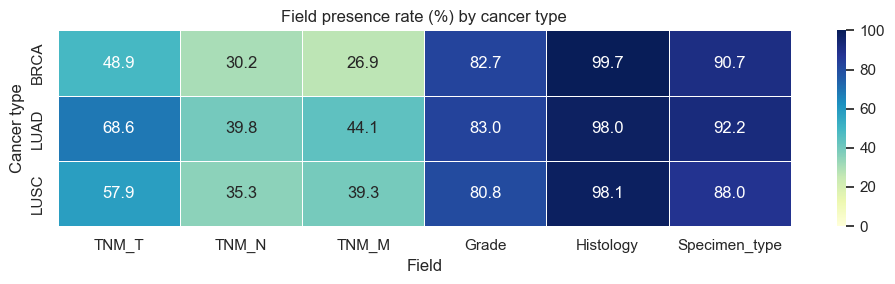

In [42]:
# Heatmap: field presence rate by cancer type
heatmap_data = []
for ct in PILOT_TYPES:
    row = {}
    subset = pilot_df[pilot_df["cancer_type"] == ct]
    for field in field_patterns:
        row[field] = subset[f"has_{field}"].mean() * 100
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=PILOT_TYPES)

fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    ax=ax,
    linewidths=0.5,
)
ax.set_title("Field presence rate (%) by cancer type")
ax.set_xlabel("Field")
ax.set_ylabel("Cancer type")
plt.tight_layout()
plt.show()

## 8. Group A Field Presence (Patient Identification)

Assessing whether sex, date of birth, or patient ID appear in TCGA report text.

In [43]:
group_a_patterns = {
    "Sex_gender": r"\b(male|female|sex\s*:|gender\s*:|man\b|woman\b)\b",
    "Date_of_birth": r"\b(DOB|date\s+of\s+birth|born|d\.o\.b\.)\b|\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
    "Patient_ID_header": r"patient\s+(id|no|number|#)\s*[:=]?",
    "Age": r"\bage[d]?\s+\d+|\b\d{2}[- ]year[- ]old|\bage\s*:\s*\d+",
}

print("Group A field presence across all pilot reports:")
print(f"{'Field':<22} {'Present':>10} {'Total':>8} {'Rate':>8}")
print("-" * 52)
for field, pattern in group_a_patterns.items():
    pilot_df[f"has_groupA_{field}"] = pilot_df["text"].apply(lambda t: field_present(t, pattern))
    n = pilot_df[f"has_groupA_{field}"].sum()
    total_n = len(pilot_df)
    rate = n / total_n * 100
    print(f"{field:<22} {n:>10,} {total_n:>8,} {rate:>7.1f}%")

Group A field presence across all pilot reports:
Field                     Present    Total     Rate
----------------------------------------------------
Sex_gender                    275    1,990    13.8%
Date_of_birth                  37    1,990     1.9%
Patient_ID_header              19    1,990     1.0%
Age                             9    1,990     0.5%


In [44]:
print("\nGroup A presence by cancer type:")
for field in group_a_patterns:
    col = f"has_groupA_{field}"
    print(f"\n{field}:")
    for ct in PILOT_TYPES:
        subset = pilot_df[pilot_df["cancer_type"] == ct]
        n = subset[col].sum()
        rate = n / len(subset) * 100
        print(f"  {ct}: {n}/{len(subset)} ({rate:.1f}%)")


Group A presence by cancer type:

Sex_gender:
  BRCA: 227/1034 (22.0%)
  LUAD: 16/488 (3.3%)
  LUSC: 32/468 (6.8%)

Date_of_birth:
  BRCA: 23/1034 (2.2%)
  LUAD: 2/488 (0.4%)
  LUSC: 12/468 (2.6%)

Patient_ID_header:
  BRCA: 11/1034 (1.1%)
  LUAD: 6/488 (1.2%)
  LUSC: 2/468 (0.4%)

Age:
  BRCA: 8/1034 (0.8%)
  LUAD: 1/488 (0.2%)
  LUSC: 0/468 (0.0%)


In [45]:
# Sample reports containing sex/gender reference
sex_samples = pilot_df[pilot_df["has_groupA_Sex_gender"]]["text"].head(3)
print("\n--- Sample reports with sex/gender mention (first 400 chars) ---")
for i, text in sex_samples.items():
    match = re.search(group_a_patterns["Sex_gender"], text, re.IGNORECASE)
    if match:
        start = max(0, match.start() - 100)
        end = min(len(text), match.end() + 200)
        print(f"\nReport index {i}:")
        print(f"  ...{text[start:end]}...")


--- Sample reports with sex/gender mention (first 400 chars) ---

Report index 6:
  ... excision: - Negative for malignancy. pT3, NO, Mx. Clinical Information: The patient is E. year-old male with lung cancer. Frozen Section Diagnosis. A1: Tonsil, left, biopsy: - Negative for malignancy. B1: Lymph node, #7, excision:- Negative for malignancy. C1: Lymph node, #9, excision: - Negative for m...

Report index 13:
  ...rior breast. CLINICAL NOTES. PRE-OP DIAGNOSIS: Left breast cancer. CLINICAL HISTORY: year-old white female with cancer. POST-OP DIAGNOSIS: Same. GROSS DESCRIPTION. A. Received fresh labeled "left axillary node" is a 3.8. x. 2.4 x 0.6 cm. portion of soft, lobulated golden-yellow. adipose tissue. Two (2) sl...

Report index 17:
  ...PATIENT HISTORY: The patient is a -year-oid female with no clinical history or LMP given. PRE-OP DIAGNOSIS: Right breast CA. POST-OP DIAGNOSIS: Same. PROCEDURE: Right segmental mastéctomy, sentinel node. ADDENDA: Addendum. ESTROGEN/PROGESTERONE AND

In [46]:
# Sample reports containing date patterns
dob_samples = pilot_df[pilot_df["has_groupA_Date_of_birth"]]["text"].head(3)
print("\n--- Sample reports with date/DOB mention (context window) ---")
for i, text in dob_samples.items():
    match = re.search(group_a_patterns["Date_of_birth"], text, re.IGNORECASE)
    if match:
        start = max(0, match.start() - 80)
        end = min(len(text), match.end() + 200)
        print(f"\nReport index {i}:")
        print(f"  ...{text[start:end]}...")


--- Sample reports with date/DOB mention (context window) ---

Report index 7:
  ...REAST. LATERALITY: Right. PROCEDURE: Simple mastectomy. Site: breast, NOS C50-9 3/0/11 her. Not specified. SIZE OF TUMOR: Maximum dimension invasive component: 1.3 cm. MULTICENTRICITY/MULTIFOCALITY OF INVASIVE FOCI: TUMOR AGGREGATE SIZE: Sum of the sizes of multiple invasive tumors: 2....

Report index 118:
  ...Progesterone Receptor: Negative (0%). > 4% Is Positive. 2-4% is Borderline. for 4/10/11. < 2% Is Negative. KI-67 (MIB1) Proliferation Marker: Low (<10%). > 20% Is High. 10-20% is Borderline. < 10% is Low. These results were interpreted by E. An additional addendum report will follow whe...

Report index 124:
  ...bular score: 3 (<10% tubule). Nuclear grade: 3. Mitotic score (Olympus 40x): 2 (7-13/10. Modified Scarff Bloom Richardson Grade: III (8-9 points). Necrosis: Absent. Vascular/Lymphatic Invasion: None identified. Lobular neoplasia: None. Lymph nodes: Sentinel lymph node only. Lymph node 

### Group A Interpretation

**Sex/gender** (13.8% overall): Appears incidentally in clinical history prose ("the patient is a 54-year-old female"), not in a dedicated header. Presence is highest in BRCA (22.0%), lower in LUAD (3.3%) and LUSC (6.8%). Extractable where present, but not universally available.

**Date of birth** (1.9%): The ~2% hit rate reflects false positives from date patterns in other contexts (e.g., biopsy dates, IHC result dates), not actual birth dates. TCGA data is de-identified; true DOB values are absent. This field is **not extractable** from report text.

**Patient ID in header** (1.0%) and **Age** (0.5%): Both are near-absent. Patient ID is the `patient_filename` key — it is not embedded in report text. Age occasionally appears in narrative introductions but is too sparse to rely on.

**Conclusions for `mission.md` Group A table:**
- `sex`: Conditionally present — extractable where a clinical history sentence exists. Flag as `null` when absent; do not hallucinate.
- `date_of_birth`: Not extractable from TCGA text. Flag as `N/A` for this proxy dataset.
- `institution_id`: Derivable from the TCGA site code in `patient_filename` (e.g. `TCGA-44-...` → site `44`) — not from report text.
- `clinical_process_number`: Maps to `patient_filename` — not present inside report text.

## 9. Summary & Hypotheses

In [217]:
brca_count = counts.get("BRCA", 0)
luad_count = counts.get("LUAD", 0)
lusc_count = counts.get("LUSC", 0)

median_tokens = int(pilot_df["token_count"].median())
p95_tokens    = int(pilot_df["token_count"].quantile(0.95))
max_tokens    = int(pilot_df["token_count"].max())
pct_over_8k   = (pilot_df["token_count"] > CONTEXT_LIMIT).mean() * 100

style_dist = pilot_df["style"].value_counts(normalize=True) * 100
style_n    = pilot_df["style"].value_counts()

sex_rate   = pilot_df["has_groupA_Sex_gender"].mean() * 100
dob_rate   = pilot_df["has_groupA_Date_of_birth"].mean() * 100
tnm_t_rate = pilot_df["has_TNM_T"].mean() * 100
grade_rate = pilot_df["has_Grade"].mean() * 100

# Data quality vars (Section 5)
n_headers   = int(pilot_df["has_headers"].sum())
pct_headers = pilot_df["has_headers"].mean() * 100
n_ocr       = int(pilot_df["ocr_noise"].sum())
pct_ocr     = pilot_df["ocr_noise"].mean() * 100
n_dup       = int(pilot_df["duplicate_content"].sum())
pct_dup     = pilot_df["duplicate_content"].mean() * 100
_bkt = (
    pilot_df["token_bucket"]
    .value_counts()
    .reindex(["very_short", "short", "medium", "long"])
    .fillna(0)
    .astype(int)
    .to_dict()
)

summary = f"""
╔══════════════════════════════════════════════════════════════════════╗
║         PHASE 1: DATA UNDERSTANDING — EDA SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  SUCCESS CRITERION 1: Join match rate                                ║
║    Match rate : {match_rate:.1f}% ({matched:,}/{total:,} reports joined)              ║
║    Unmatched  : {unmatched} reports                                         ║
║    Status     : {'PASS' if match_rate > 90 else 'WARN'}                                             ║
║                                                                      ║
║  SUCCESS CRITERION 2: Pilot subset confirmed (≥ 100 per type)        ║
║    BRCA : {brca_count:,} reports  {'PASS' if brca_count >= 100 else 'FAIL'}                                ║
║    LUAD : {luad_count:,} reports  {'PASS' if luad_count >= 100 else 'FAIL'}                                ║
║    LUSC : {lusc_count:,} reports  {'PASS' if lusc_count >= 100 else 'FAIL'}                                ║
║                                                                      ║
║  SUCCESS CRITERION 3: Token length distribution & threshold          ║
║    Median tokens : {median_tokens:,}                                       ║
║    p95 tokens    : {p95_tokens:,}                                       ║
║    Max tokens    : {max_tokens:,}                                      ║
║    Over 8k limit : {pct_over_8k:.1f}% of pilot reports                    ║
║    Threshold set : {CONTEXT_LIMIT:,} tokens (first N tokens retained)       ║
║    Status        : PASS                                              ║
║                                                                      ║
║  SUCCESS CRITERION 4: All pilot reports classified by style          ║
║    Method     : automated rule-based classifier                      ║
║    Classified : {len(pilot_df):,} reports                                    ║
║    Synoptic   : {style_dist.get('synoptic', 0):.0f}% (n={style_n.get('synoptic', 0):,})                               ║
║    Mixed      : {style_dist.get('mixed', 0):.0f}% (n={style_n.get('mixed', 0):,})                               ║
║    Narrative  : {style_dist.get('narrative', 0):.0f}% (n={style_n.get('narrative', 0):,})                                ║
║    Status     : PASS                                                 ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  DATA QUALITY FLAGS (pilot corpus, n={len(pilot_df):,})                      ║
║    Structural headers : {n_headers:>4} reports  ({pct_headers:5.1f}%)                  ║
║    OCR noise flagged  : {n_ocr:>4} reports  ({pct_ocr:5.1f}%)                  ║
║    Duplicate content  : {n_dup:>4} reports  ({pct_dup:5.1f}%)                  ║
║    Token buckets:                                                    ║
║      very_short (<100 tk) : {_bkt.get('very_short', 0):>4}                             ║
║      short  (100–500 tk)  : {_bkt.get('short', 0):>4}                             ║
║      medium (500–2k tk)   : {_bkt.get('medium', 0):>4}                             ║
║      long   (>2k tk)      : {_bkt.get('long', 0):>4}                             ║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  KEY FIELD PRESENCE (all pilot reports)                              ║
║    TNM T stage  : {tnm_t_rate:.1f}% of reports                             ║
║    Tumor grade  : {grade_rate:.1f}% of reports                             ║
║    Sex/gender   : {sex_rate:.1f}% of reports                             ║
║    Date of birth: {dob_rate:.1f}% of reports (TCGA de-identified; ~0% expected)║
║                                                                      ║
╠══════════════════════════════════════════════════════════════════════╣
║  HYPOTHESES FOR PHASE 2                                              ║
║                                                                      ║
║  H1: Synoptic/mixed reports → higher extraction accuracy             ║
║      Rationale: explicit field headers act as extraction anchors.    ║
║      Test: stratify Phase 4 F1 scores by report style.              ║
║                                                                      ║
║  H2: Institution variation → differences in field completeness       ║
║      Rationale: TCGA aggregates reports from many institutions with  ║
║      varying templates and completeness standards.                   ║
║      Test: stratify Phase 4 metrics by TCGA site code.              ║
║                                                                      ║
║  GROUP A UPDATE FOR mission.md:                                      ║
║    sex          : Conditionally present in narrative intros (~14%)   ║
║    date_of_birth: NOT present (TCGA de-identified, ~2% false pos.)  ║
║    institution_id: Derivable from patient_filename, not report text  ║
║    clinical_process_number: = patient_filename, not in report text   ║
╚══════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════╗
║         PHASE 1: DATA UNDERSTANDING — EDA SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  SUCCESS CRITERION 1: Join match rate                                ║
║    Match rate : 100.0% (9,523/1,990 reports joined)              ║
║    Unmatched  : 0 reports                                         ║
║    Status     : PASS                                             ║
║                                                                      ║
║  SUCCESS CRITERION 2: Pilot subset confirmed (≥ 100 per type)        ║
║    BRCA : 1,034 reports  PASS                                ║
║    LUAD : 488 reports  PASS                                ║
║    LUSC : 468 reports  PASS                                ║
║                                                                      ║
║  SUCCESS CRITERI